Folders in weather directory: ['rain', 'shine', 'sunrise', 'cloudy']
Found 493 images belonging to 2 classes.
Found 164 images belonging to 2 classes.
Class indices: {'cloudy': 0, 'sunrise': 1}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7253 - loss: 0.4707 - val_accuracy: 0.9756 - val_loss: 0.1951
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9329 - loss: 0.1919 - val_accuracy: 0.9634 - val_loss: 0.1178
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9730 - loss: 0.0988 - val_accuracy: 0.9756 - val_loss: 0.1099
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9877 - loss: 0.0528 - val_accuracy: 0.9817 - val_loss: 0.0861
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9887 - loss: 0.0371 - val_accuracy: 0.9756 - val_loss: 0.0617
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9814 - loss: 0.0677 - val_accuracy: 0.9756 - val_loss: 0.0578
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9790 - loss: 0.0469 - val_accuracy: 0.9817 - val_loss: 0.0599
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9806 - loss: 0.0565 - val_accuracy: 0.9756 - val_loss:

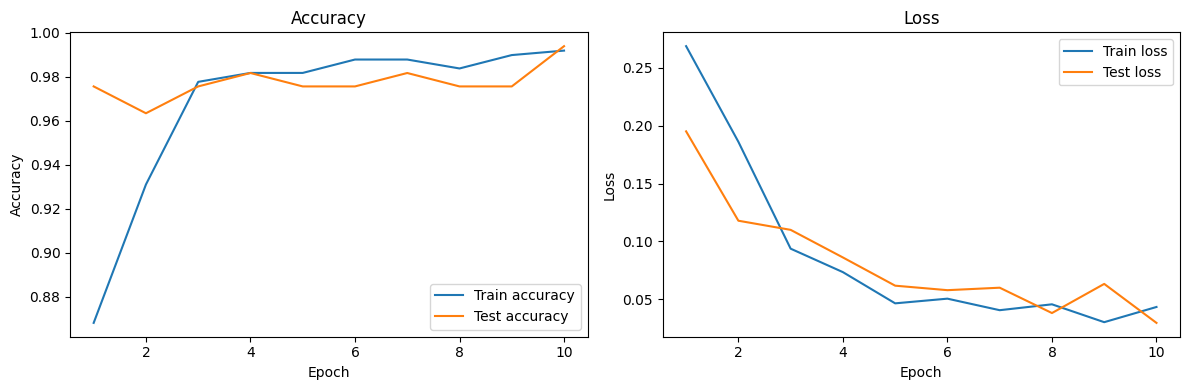

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 369ms/step
Confusion matrix:
 [[74  1]
 [ 0 89]]
Accuracy: 0.9939024390243902
Cohen's kappa: 0.9877024595080984

Classification report:

              precision    recall  f1-score   support

      cloudy       1.00      0.99      0.99        75
     sunrise       0.99      1.00      0.99        89

    accuracy                           0.99       164
   macro avg       0.99      0.99      0.99       164
weighted avg       0.99      0.99      0.99       164



In [8]:
##################### IMPORTY I ROZPAKOWANIE DANYCH #################

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, cohen_kappa_score

zip_path = "/content/weather.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

data_dir = "/content/weather"

print("Folders in weather directory:", os.listdir(data_dir))

############### GENERATORY DANYCH, PODZIAL 75/25 ##################

img_height = 150
img_width = 150
batch_size = 32

# Data generators with train/test split (75% / 25%)
datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.25  # 25% will be used as test set
)

# We explicitly choose only two classes: 'cloudy' and 'sunrise'
classes_to_use = ['cloudy', 'sunrise']

# Training generator (75% of images)
train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    classes=classes_to_use,   # only these folders will be used
    class_mode='binary',      # 2 classes => binary classification
    subset='training',
    shuffle=True,
    seed=42
)

# Test generator (25% of images)
test_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    classes=classes_to_use,
    class_mode='binary',
    subset='validation',      # same split as above
    shuffle=False,            # important for metrics (order must be fixed)
    seed=42
)

print("Class indices:", train_gen.class_indices)

################### SIEC CNN DO KLASYFIKACJI 2 KLAS ###################

model = models.Sequential([
    # Convolution + pooling blocks
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten + dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')   # sigmoid -> probability of class 1
])

model.summary()

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # standard loss for binary classification
    metrics=['accuracy']
)

##################### TRENOWANIE NA 75% OBRAZOW ####################

epochs = 10

history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=test_gen,  # 25% split as test set
    verbose=1
)

############# WYKRES PRZEBIEGU UCZENIA - ACCURACY + LOSS ############

# Plot training & validation accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train accuracy')
plt.plot(epochs_range, val_acc, label='Test accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train loss')
plt.plot(epochs_range, val_loss, label='Test loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

########################### EWALUACJA #########################

# 1. Get true labels from the generator
y_true = test_gen.classes  # array with 0/1 for each image in the test generator

# 2. Get predicted probabilities from the model
test_gen.reset()  # reset to make sure we go through images in correct order
y_prob = model.predict(test_gen)
# 3. Convert probabilities to class labels (0 or 1)
y_pred = (y_prob > 0.5).astype(int).ravel()

# 4. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

# 5. Accuracy
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

# 6. Cohen's kappa
kappa = cohen_kappa_score(y_true, y_pred)
print("Cohen's kappa:", kappa)

# 7. classification report (precision, recall, F1)
target_names = classes_to_use
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))


Zastosowana sieć CNN osiągnęła bardzo wysoką skuteczność klasyfikacji obrazów na dwie klasy (cloudy, sunrise). Po 10 epokach treningu dokładność na zbiorze uczącym wyniosła ok. 99,3%, a na zbiorze testowym ok. 99,4%. Macierz pomyłek pokazuje jedynie jedno błędnie sklasyfikowane zdjęcie spośród 164 przykładów testowych. Współczynnik Cohen’s kappa równy 0,99 świadczy o niemal idealnej zgodności predykcji modelu z etykietami rzeczywistymi

Found 843 images belonging to 4 classes.
Found 280 images belonging to 4 classes.
Class indices (4-class): {'cloudy': 0, 'rain': 1, 'shine': 2, 'sunrise': 3}


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.5243 - loss: 1.0441 - val_accuracy: 0.6786 - val_loss: 0.8095
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7715 - loss: 0.6218 - val_accuracy: 0.7571 - val_loss: 0.6111
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8583 - loss: 0.4121 - val_accuracy: 0.8250 - val_loss: 0.4851
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9088 - loss: 0.2833 - val_accuracy: 0.8429 - val_loss: 0.4798
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9245 - loss: 0.2601 - val_accuracy: 0.8429 - val_loss: 0.4615
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9237 - loss: 0.2734 - val_accuracy: 0.8143 - val_loss: 0.5111
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8991 - loss: 0.2957 - val_accuracy: 0.8214 - val_loss: 0.4335
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9411 - loss: 0.2005 - val_accuracy: 0.8286 - val_loss:

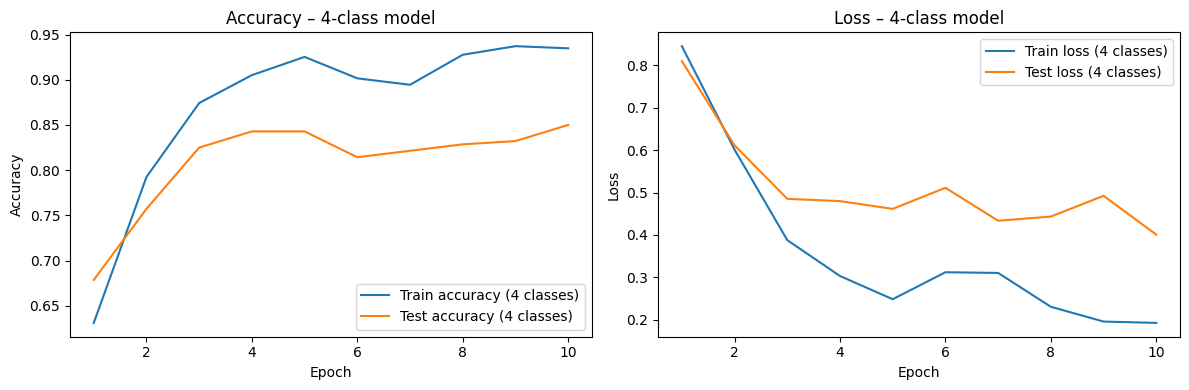

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 422ms/step
Confusion matrix (4 classes):
 [[48  0 26  1]
 [ 5 47  1  0]
 [ 3  1 59  0]
 [ 1  0  4 84]]
Accuracy (4 classes): 0.85
Cohen's kappa (4 classes): 0.7984437664964179

Classification report (4 classes):

              precision    recall  f1-score   support

      cloudy       0.84      0.64      0.73        75
        rain       0.98      0.89      0.93        53
       shine       0.66      0.94      0.77        63
     sunrise       0.99      0.94      0.97        89

    accuracy                           0.85       280
   macro avg       0.87      0.85      0.85       280
weighted avg       0.87      0.85      0.85       280



In [10]:
################### Part 2 – 4-class classification #####################


from tensorflow.keras.preprocessing.image import ImageDataGenerator

classes_4 = ['cloudy', 'rain', 'shine', 'sunrise']

# 75/25 split
datagen_4 = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.25
)

# Training generator (75% of images)
train_gen_4 = datagen_4.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    classes=classes_4,        # 4 classes
    class_mode='categorical', # multi-class classification
    subset='training',
    shuffle=True,
    seed=42
)

# Test/validation generator (25% of images)
test_gen_4 = datagen_4.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    classes=classes_4,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print("Class indices (4-class):", train_gen_4.class_indices)


################### MODEL CNN DLA 4 KLAS ############################

from tensorflow.keras import layers, models

num_classes_4 = len(classes_4)

model_4 = models.Sequential([
    # Convolution + pooling blocks
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten + dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer for 4 classes (softmax gives probability for each class)
    layers.Dense(num_classes_4, activation='softmax')
])

model_4.summary()

# Compile the 4-class model
model_4.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # loss for multi-class classification
    metrics=['accuracy']
)


########################## TRENOWANIE 75% ########################

epochs_4 = 10

history_4 = model_4.fit(
    train_gen_4,
    epochs=epochs_4,
    validation_data=test_gen_4,
    verbose=1
)

################ WYKRESY ACCURACY + LOSS ########################

# Plot training & validation accuracy and loss for 4-class model

acc_4 = history_4.history['accuracy']
val_acc_4 = history_4.history['val_accuracy']

loss_4 = history_4.history['loss']
val_loss_4 = history_4.history['val_loss']

epochs_range_4 = range(1, len(acc_4) + 1)

plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range_4, acc_4, label='Train accuracy (4 classes)')
plt.plot(epochs_range_4, val_acc_4, label='Test accuracy (4 classes)')
plt.title('Accuracy – 4-class model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range_4, loss_4, label='Train loss (4 classes)')
plt.plot(epochs_range_4, val_loss_4, label='Test loss (4 classes)')
plt.title('Loss – 4-class model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

############################ EWALUACJA ######################
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, cohen_kappa_score
import numpy as np

# 1. True labels (0,1,2,3) from generator
y_true_4 = test_gen_4.classes

# 2. Predicted probabilities for each class
test_gen_4.reset()
y_prob_4 = model_4.predict(test_gen_4)

# 3. Convert probabilities to predicted class index (argmax)
y_pred_4 = np.argmax(y_prob_4, axis=1)

# 4. Confusion matrix
cm_4 = confusion_matrix(y_true_4, y_pred_4)
print("Confusion matrix (4 classes):\n", cm_4)

# 5. Accuracy
acc_eval_4 = accuracy_score(y_true_4, y_pred_4)
print("Accuracy (4 classes):", acc_eval_4)

# 6. Cohen's kappa
kappa_4 = cohen_kappa_score(y_true_4, y_pred_4)
print("Cohen's kappa (4 classes):", kappa_4)

# 7. Detailed classification report
print("\nClassification report (4 classes):\n")
print(classification_report(y_true_4, y_pred_4, target_names=classes_4))


Class indices: {'cloudy': 0, 'rain': 1, 'shine': 2, 'sunrise': 3}
cloudy   (index 0) -> [1. 0. 0. 0.]
rain     (index 1) -> [0. 1. 0. 0.]
shine    (index 2) -> [0. 0. 1. 0.]
sunrise  (index 3) -> [0. 0. 0. 1.]
x_batch shape: (32, 150, 150, 3)
y_batch shape: (32, 4)


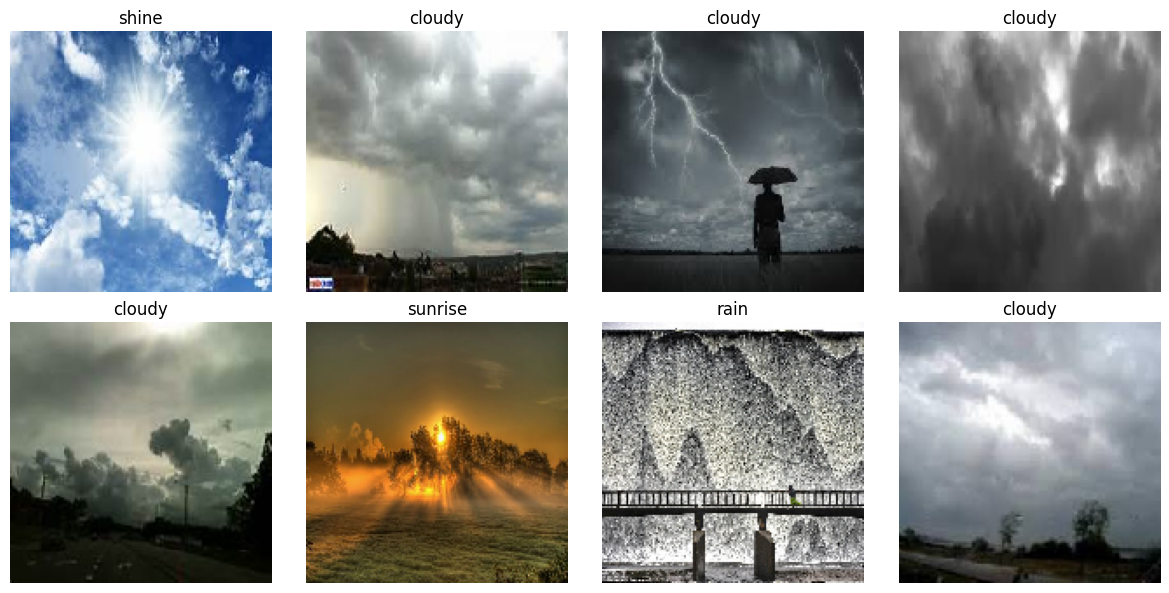

In [13]:
##### Przetestowanie fragmentu kodu z one hot encoding i wyswietlenie przykladowych zdjec z podpisami

import numpy as np

print("Class indices:", train_gen_4.class_indices)

num_classes_4 = len(classes_4)

for class_name, idx in train_gen_4.class_indices.items():
    one_hot_vec = np.eye(num_classes_4)[idx]
    print(f"{class_name:8s} (index {idx}) -> {one_hot_vec}")


import matplotlib.pyplot as plt

x_batch, y_batch = next(train_gen_4)

print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)


plt.figure(figsize=(12, 6))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(x_batch[i])
    label_idx = np.argmax(y_batch[i])
    label_name = classes_4[label_idx]
    plt.title(label_name)
    plt.axis("off")

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step


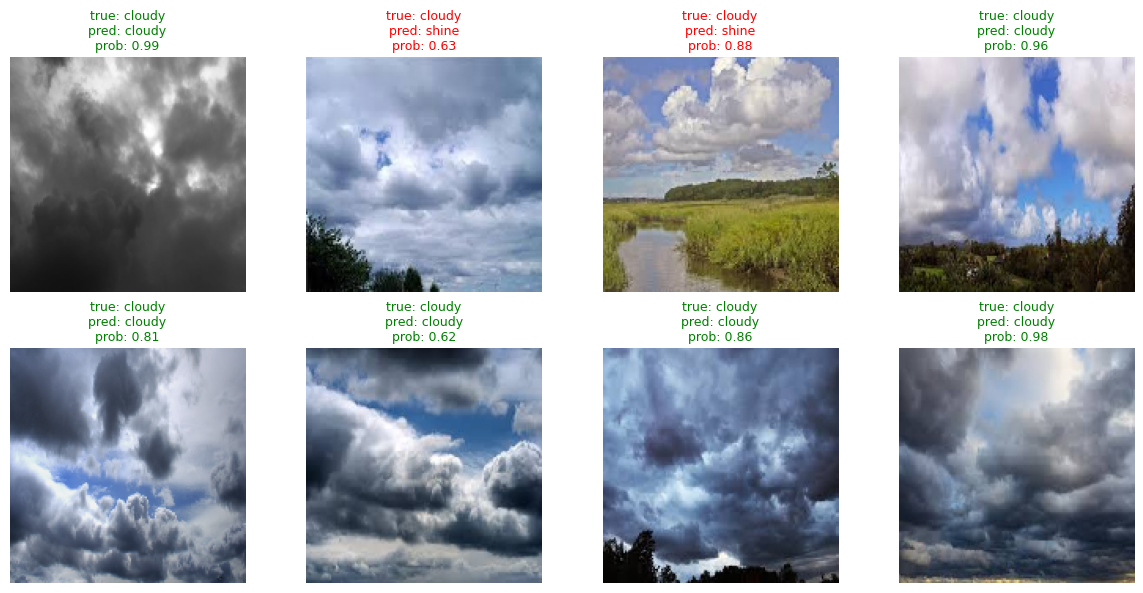

In [14]:
#### przetestowanie przewidywan modelu wraz z rzeczywistymi kategoriami
import numpy as np
import matplotlib.pyplot as plt

test_gen_4.reset()
x_batch, y_batch_true = next(test_gen_4)
y_batch_prob = model_4.predict(x_batch)

y_true_idx = np.argmax(y_batch_true, axis=1)   # prawdziwe klasy (0..3)
y_pred_idx = np.argmax(y_batch_prob, axis=1)   # przewidziane klasy (0..3)


plt.figure(figsize=(12, 6))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(x_batch[i])

    true_label = classes_4[y_true_idx[i]]   # nazwa prawdziwej klasy
    pred_label = classes_4[y_pred_idx[i]]   # nazwa przewidzianej klasy
    prob = np.max(y_batch_prob[i])          # pewność modelu dla przewidzianej klasy

    # Zielony tytuł = poprawna klasyfikacja, czerwony = błąd
    color = "green" if y_true_idx[i] == y_pred_idx[i] else "red"
    plt.title(f"true: {true_label}\npred: {pred_label}\nprob: {prob:.2f}",
              color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


W zadaniu czteroklasowej klasyfikacji (cloudy, rain, shine, sunrise) zastosowana sieć CNN osiągnęła dokładność ok. 85% na zbiorze testowym. Współczynnik Cohen’s kappa na poziomie ok. 0,80 wskazuje na wysoką zgodność predykcji modelu z etykietami rzeczywistymi, znacząco powyżej losowego zgadywania.

Najlepiej rozpoznawane są zdjęcia kategorii sunrise oraz rain (f1-score odpowiednio 0,97 i 0,93). Najwięcej trudności sprawia klasa cloudy – model myli część pochmurnych zdjęć z klasą shine, co odzwierciedla relatywnie niższą czułość (recall = 0,64). Wynika to prawdopodobnie z podobieństwa wizualnego części zdjęć pochmurnych i słonecznych. Mimo to uzyskane wyniki można uznać za satysfakcjonujące jak na czteroklasowy problem klasyfikacji obrazów z prostą architekturą CNN.